In [7]:
import pandas as pd
def parsedata(data, quantum=False):
    data = data[1:]
    df = pd.DataFrame()
    df["oversampled"] = []
    df["undersampled"] = []
    df["features"] = []
    df["accuracy"] = []
    df["auroc"] = []
    df["prauc"] = []
    for block in data:
        lines = block.split("\n")
        oversampled = "oversampled" in lines[0]
        undersampled = "undersampled" in lines[0]
        if "521" in lines[0]:
            features = 521
        else:
            features = 20
        if not quantum:
            accuracy = float(lines[1].lstrip().replace("Accuracy: ",""))
            auroc = float(lines[7].lstrip().replace("AUROC: ",""))
            prauc = float(lines[8].lstrip().replace("PRAUC: ",""))
        else:
            accuracy = float(lines[1].lstrip().replace("Test accuracy: ",""))
            auroc = float(lines[8].lstrip().replace("AUROC: ",""))
            prauc = float(lines[9].lstrip().replace("PRAUC: ",""))
        df.loc[len(df)] = [oversampled, undersampled, features, accuracy, auroc, prauc]
        
    return df

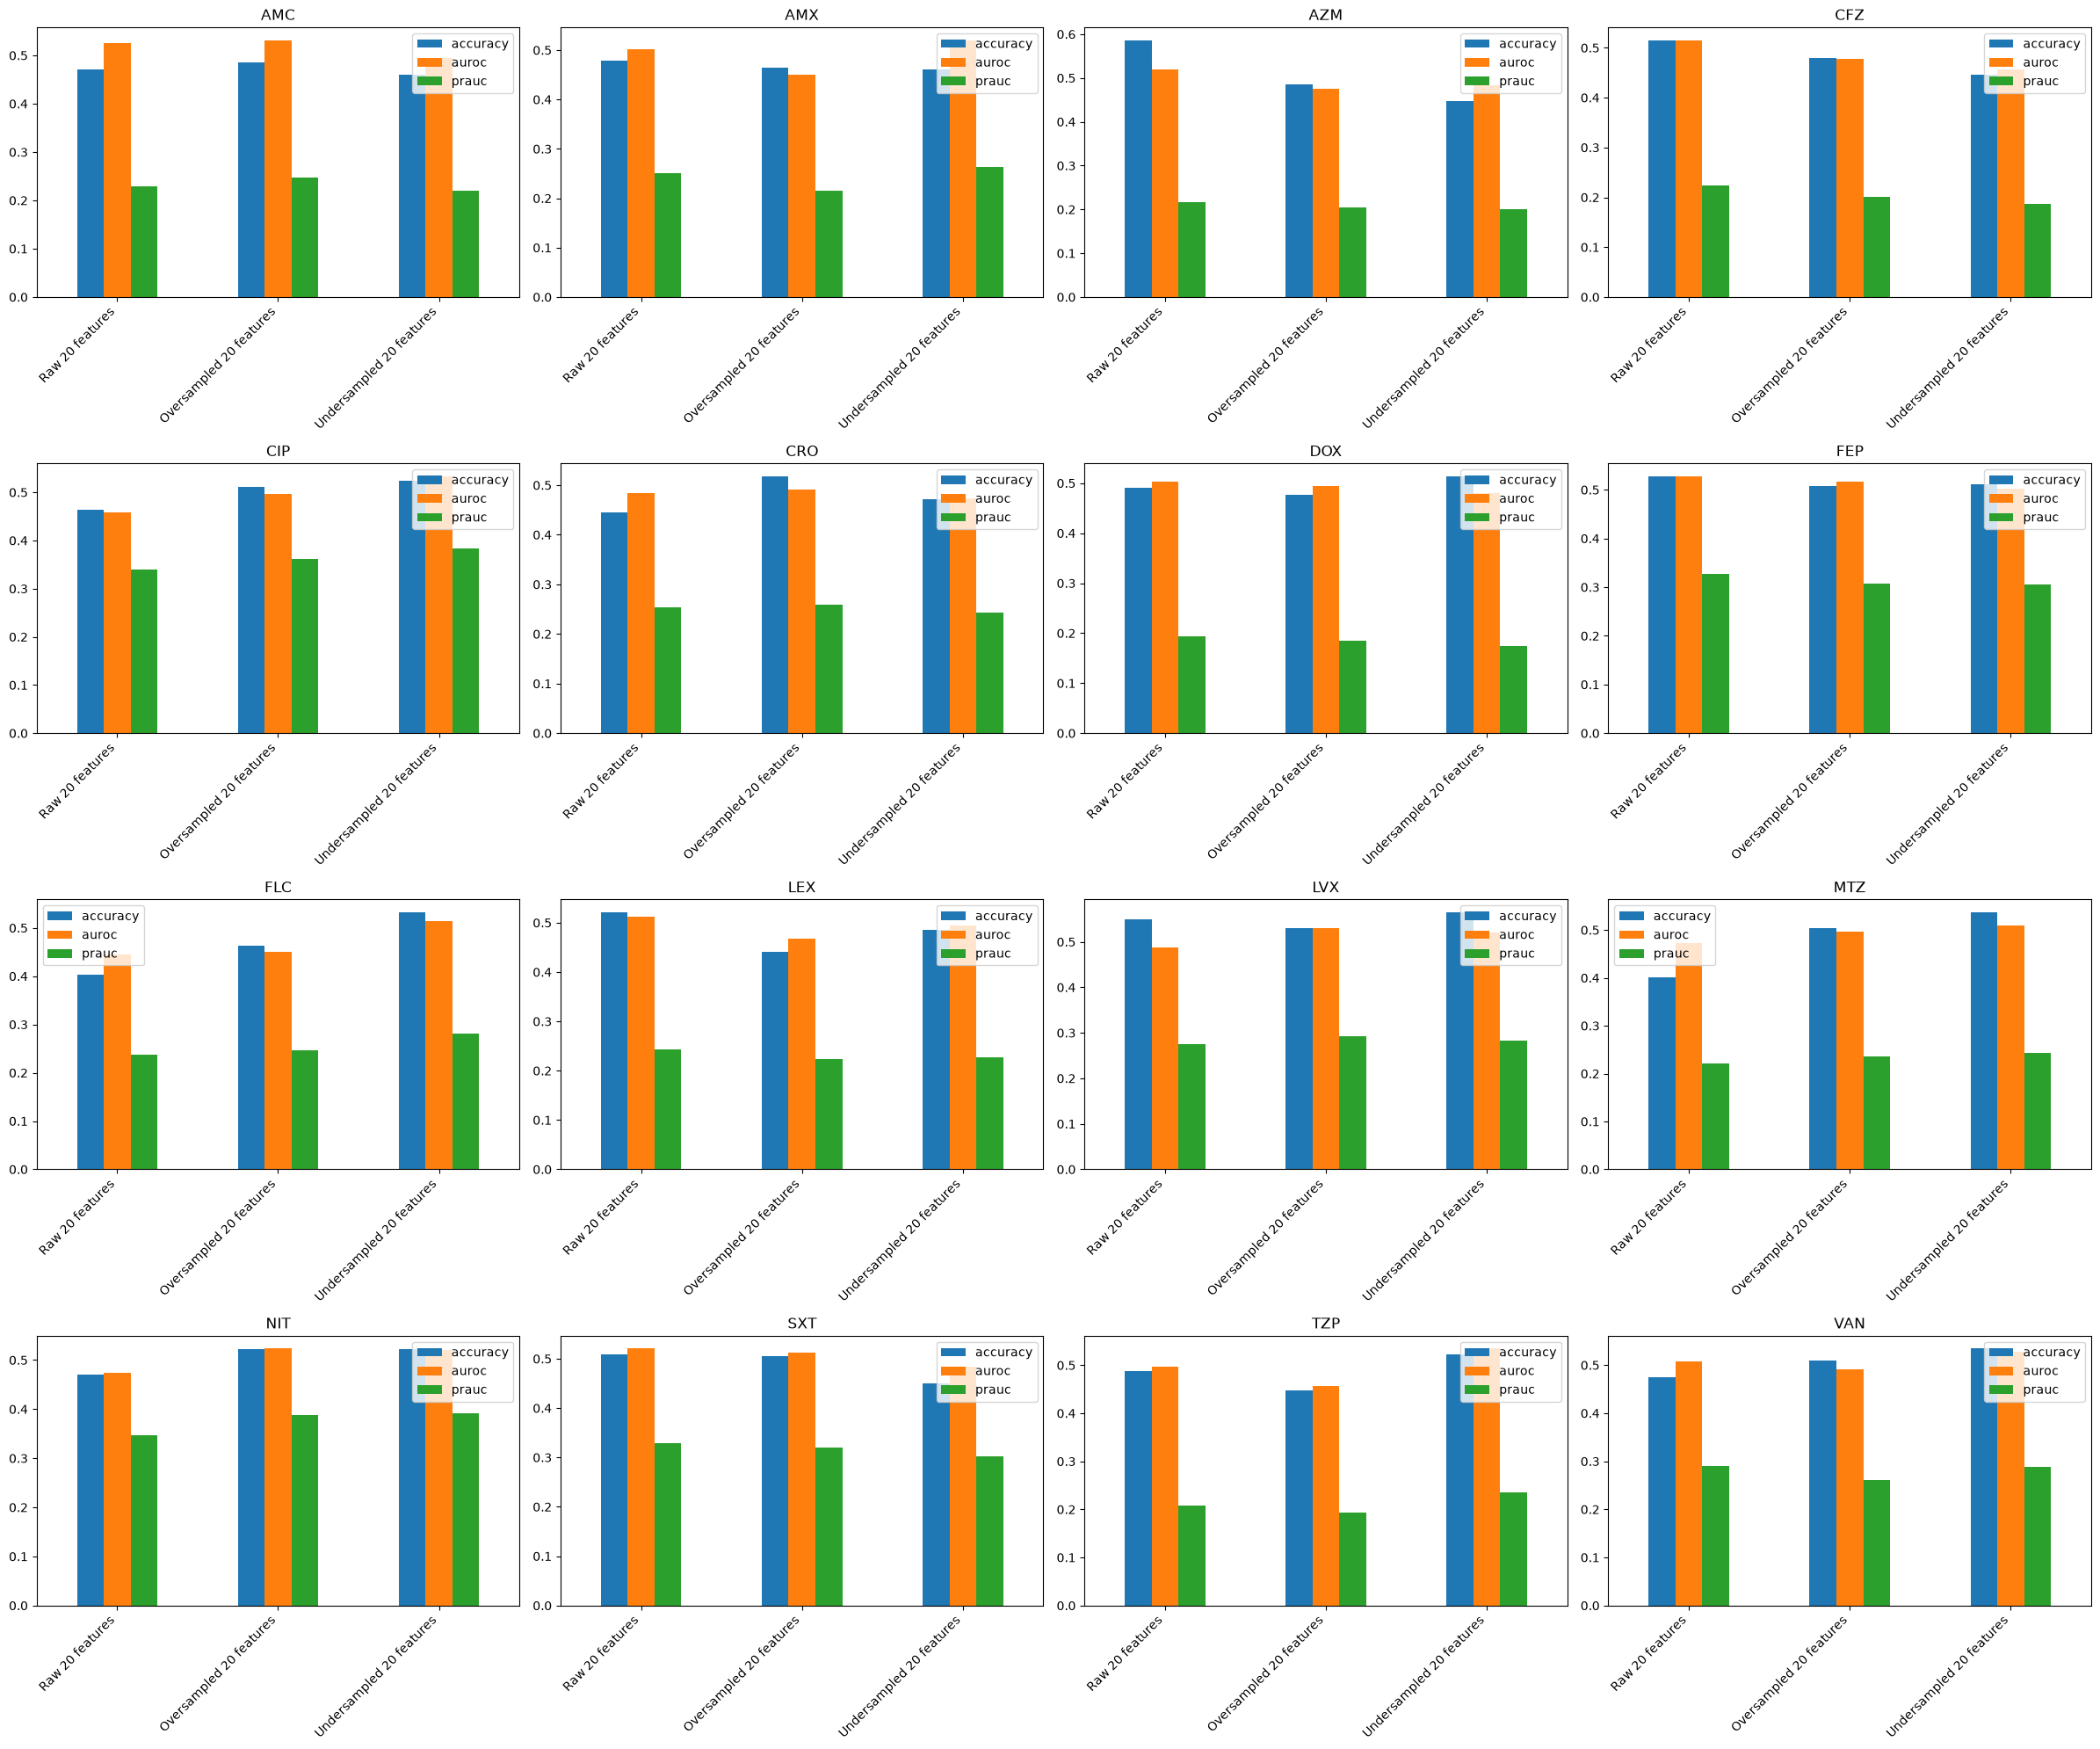

In [8]:
import matplotlib.pyplot as plt
import numpy as np
drugs_list = ["AMC", "AMX", "AZM", "CFZ", "CIP", "CRO", "DOX", "FEP", "FLC", "LEX", "LVX", "MTZ", "NIT", "SXT", "TZP", "VAN"]
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 20))
axes_flat = axes.flatten()

for i in range(len(drugs_list)):
    DRUG = drugs_list[i]
    with open(f"QML Results/{DRUG}.txt", "r") as file:
        data = "".join(file.readlines()).split(DRUG)
        df = parsedata(data, True)
        conditions = [
            df["oversampled"],
            df["undersampled"]
        ]
        choices = [
            "Oversampled " + df["features"].astype(str) + " features",
            "Undersampled " + df["features"].astype(str) + " features"
        ]
        df["Labels"] = np.select(conditions, choices, default="Raw " + df["features"].astype(str) + " features")
        df.plot(kind="bar",y=["accuracy","auroc","prauc"], title=DRUG, x="Labels", ax=axes_flat[i])
        axes_flat[i].set_xticklabels(axes_flat[i].get_xticklabels(), rotation=45, ha='right')
        axes_flat[i].set_xlabel('')
plt.tight_layout()
plt.show()
